<a href="https://colab.research.google.com/github/codewithpiki/README.md/blob/main/housingprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Replace 'your_file_name.csv' with the actual name of the file you uploaded
# Tip: Right-click the file in the sidebar and select "Copy path" to get the exact link
df = pd.read_csv('/content/housing.csv.zip')

# Look at the first 5 rows to make sure it loaded correctly
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# 1. Check which columns have missing data
print("Missing values per column:")
print(df.isnull().sum())

# 2. Handle missing numerical data (Example: Age)
# We use 'fillna' to replace NaN with the median
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())

# 3. Handle missing categorical data (Example: City)
# We fill it with a placeholder like "Unknown"
if 'City' in df.columns:
    df['City'] = df['City'].fillna('Unknown')

# 4. Verify that there are no more missing values
print("\nCleaned Data Check:")
print(df.isnull().sum())

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Cleaned Data Check:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [6]:
# Compute Mean, Median, and Standard Deviation for a column (e.g., 'Score' or 'Price')
# Change 'Column_Name' to a numeric column in your dataset
target_col = 'median_house_value' # Changed from 'Score' to an existing numeric column

mean_val = df[target_col].mean()
median_val = df[target_col].median()
std_dev = df[target_col].std()

print(f"Analysis for {target_col}:")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")

Analysis for median_house_value:
Mean: 206855.82
Median: 179700.00
Standard Deviation: 115395.62


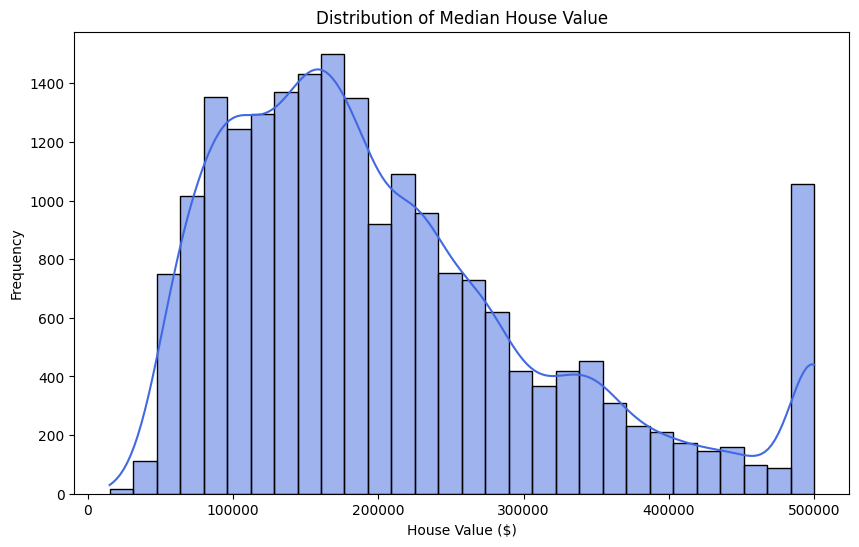

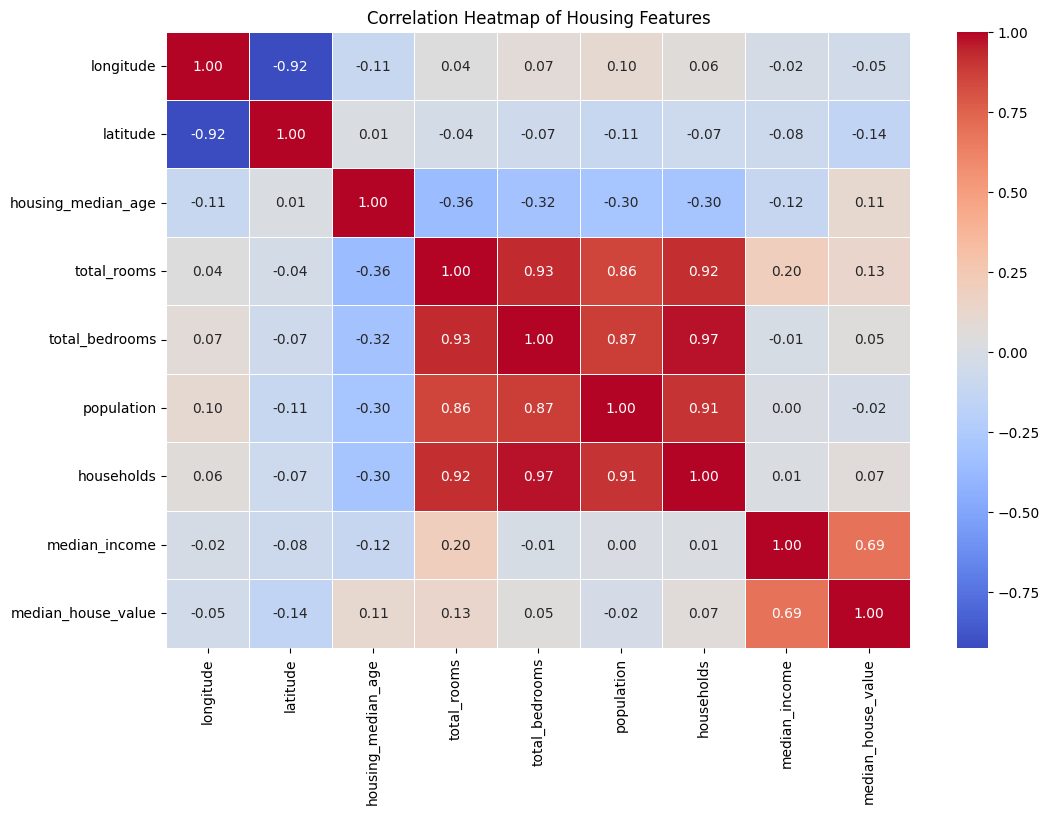

Correlation with Median House Value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the dataset
# (Make sure the filename matches the one you uploaded)
df = pd.read_csv('/content/housing.csv.zip')

# 2. Preliminary Cleaning (Handling missing values before plotting)
# Real-world housing data often has missing values in 'total_bedrooms'
df = df.fillna(df.median(numeric_only=True))

# 3. Plotting the Histogram for Median House Value
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of Median House Value')
plt.xlabel('House Value ($)')
plt.ylabel('Frequency')
plt.show()

# 4. Creating the Correlation Heatmap
plt.figure(figsize=(12, 8))
# We compute the correlation matrix for numerical features only
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features')
plt.show()

# 5. Specific check for Median Income vs House Value
print("Correlation with Median House Value:")
print(correlation_matrix['median_house_value'].sort_values(ascending=False))


In [9]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
# We drop the target variable from X
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 16512
Testing samples: 4128


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# The error indicates that 'ocean_proximity' (a categorical column) needs to be converted to numerical.
# We will apply one-hot encoding to X_train and X_test before training the model.

# Identify categorical columns in X_train
categorical_cols = X_train.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    # Apply one-hot encoding to training data
    X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=False)

    # Apply one-hot encoding to test data
    X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False)

    # Ensure both dataframes have the same columns after encoding.
    # This is crucial if some categories are present in train but not test, or vice-versa.
    # Align the columns based on the training set columns and fill missing with 0.
    X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

    X_train = X_train_encoded
    X_test = X_test_encoded


# Initialize and train
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict
y_pred_lin = lin_reg.predict(X_test)


In [14]:
from sklearn.linear_model import Ridge, Lasso

# Ridge Regression
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)

# Lasso Regression
lasso_reg = Lasso(alpha=1.0)
lasso_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.265e+12, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


Lasso()

In [17]:
from xgboost import XGBRegressor

# XGBoost can have issues with special characters in feature names.
# Sanitize column names before training.
# This issue often arises with one-hot encoded columns like 'ocean_proximity_<1H OCEAN'
# which contain the '<' character.
import re

def sanitize_column_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        # Replace problematic characters like '[', ']', '<' with '_' or remove them
        new_col = re.sub(r'[<>\[\]]', '_', col)
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_sanitized = sanitize_column_names(X_train.copy())
X_test_sanitized = sanitize_column_names(X_test.copy())

# Initialize and train
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
xgb_reg.fit(X_train_sanitized, y_train)

# Predict
y_pred_xgb = xgb_reg.predict(X_test_sanitized)


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Function to calculate and display errors
def calculate_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"--- {model_name} Evaluation ---")
    print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
    print("-" * 30)
    return rmse, mae

# Calculate for all models
lin_rmse, lin_mae = calculate_metrics(y_test, y_pred_lin, "Linear Regression")
ridge_rmse, ridge_mae = calculate_metrics(y_test, ridge_reg.predict(X_test), "Ridge")
lasso_rmse, lasso_mae = calculate_metrics(y_test, lasso_reg.predict(X_test), "Lasso")
xgb_rmse, xgb_mae = calculate_metrics(y_test, y_pred_xgb, "XGBoost")

--- Linear Regression Evaluation ---
Mean Absolute Error (MAE): $50,670.74
Root Mean Squared Error (RMSE): $70,060.52
------------------------------
--- Ridge Evaluation ---
Mean Absolute Error (MAE): $50,679.44
Root Mean Squared Error (RMSE): $70,070.20
------------------------------
--- Lasso Evaluation ---
Mean Absolute Error (MAE): $50,672.34
Root Mean Squared Error (RMSE): $70,062.16
------------------------------
--- XGBoost Evaluation ---
Mean Absolute Error (MAE): $33,856.12
Root Mean Squared Error (RMSE): $50,454.05
------------------------------
